# CTEC 450 Final Project

This project shows how machine learning models can be attacked using adversarial examples and how defense techniques can help improve security.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist

## Importing Libraries

These libraries are used to build, train, test, and display the machine learning model.

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert to float32
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

print("Dataset loaded successfully")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully


## Loading the MNIST Dataset

The MNIST dataset contains images of handwritten digits from 0 to 9. The dataset is commonly used for machine learning image classification projects.


In [3]:
# Build neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model created successfully")

Model created successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Building the Neural Network Model

A simple neural network model is created using TensorFlow and Keras. The model uses one hidden layer and one output layer to classify handwritten digits.

In [4]:
# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9223 - loss: 0.2721 - val_accuracy: 0.9640 - val_loss: 0.1210
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9646 - loss: 0.1203 - val_accuracy: 0.9720 - val_loss: 0.0920
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9753 - loss: 0.0818 - val_accuracy: 0.9758 - val_loss: 0.0828
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9815 - loss: 0.0608 - val_accuracy: 0.9758 - val_loss: 0.0805
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9851 - loss: 0.0472 - val_accuracy: 0.9748 - val_loss: 0.0803


## Training the Model

The model is trained using the MNIST training dataset. During training, the model learns patterns from the handwritten digit images.

In [5]:
# Evaluate clean model
loss, accuracy = model.evaluate(x_test, y_test)

print("Clean Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9743 - loss: 0.0823
Clean Accuracy: 0.9743000268936157


## Evaluating Accuracy

After training, the model is tested using clean images from the test dataset to measure accuracy.

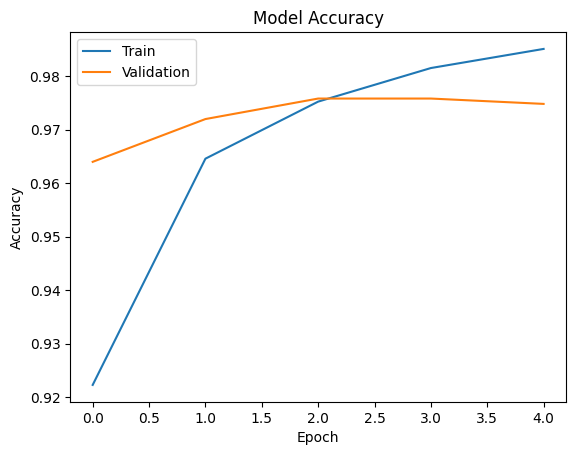

In [6]:
# Plot accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

## Accuracy Graph

The graph above shows the training accuracy and validation accuracy during the training process.

In [7]:
# FGSM attack function
def create_adversarial_pattern(image, label):

    image = tf.convert_to_tensor(image)
    image = tf.cast(image, tf.float32)

    with tf.GradientTape() as tape:

        tape.watch(image)

        prediction = model(image)

        loss = tf.keras.losses.sparse_categorical_crossentropy(
            label,
            prediction
        )

    gradient = tape.gradient(loss, image)

    signed_grad = tf.sign(gradient)

    return signed_grad

print("FGSM function ready")

FGSM function ready


## FGSM Attack

The FGSM is an adversarial attack that slightly changes image pixels to try to fool the neural network into making incorrect predictions.

In [8]:
# Select sample image
image = x_test[0]
label = y_test[0]

image = image.reshape((1, 28, 28))

label = np.array([label])

# Generate perturbation
perturbations = create_adversarial_pattern(image, label)

epsilon = 0.15

# Create adversarial image
adversarial_image = image + epsilon * perturbations

adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)

print("Adversarial image created")

Adversarial image created


## FGSM Formula

The formula below shows how adversarial images are created using FGSM.


Screenshot 2026-05-07 203900.png

In [9]:
# Compare predictions
original_prediction = model.predict(image)

adversarial_prediction = model.predict(adversarial_image)

print("Original Prediction:", np.argmax(original_prediction))

print("Adversarial Prediction:", np.argmax(adversarial_prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Original Prediction: 7
Adversarial Prediction: 3


## Comparing Predictions

The prediction for the original image is compared with the prediction for the adversarial image to see if the attack was successful.

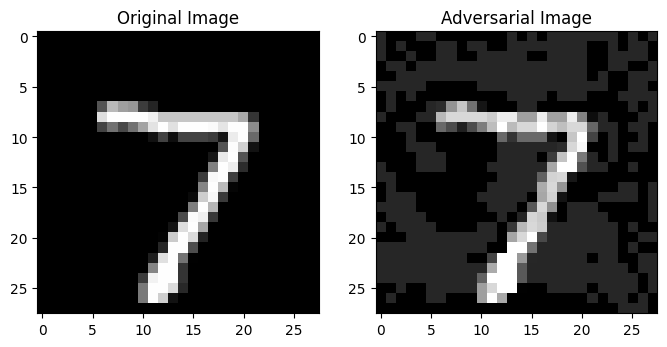

In [10]:
# Display images
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image[0], cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(adversarial_image[0], cmap='gray')
plt.title('Adversarial Image')

plt.show()

## Original and Adversarial Images
The images above show the original handwritten digit and the modified adversarial image.

In [11]:
# Measure attacked accuracy
correct = 0

sample_size = 1000

epsilon = 0.15

for i in range(sample_size):

    image = x_test[i].reshape((1, 28, 28))

    label = np.array([y_test[i]])

    perturbations = create_adversarial_pattern(image, label)

    adversarial_image = image + epsilon * perturbations

    adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)

    prediction = model.predict(adversarial_image, verbose=0)

    predicted_label = np.argmax(prediction)

    if predicted_label == y_test[i]:
        correct += 1

attacked_accuracy = correct / sample_size

print("Accuracy Under Attack:", attacked_accuracy)

Accuracy Under Attack: 0.02


## Measuring Accuracy Under Attack

The model is tested on multiple adversarial images to measure how much the attack lowers accuracy.

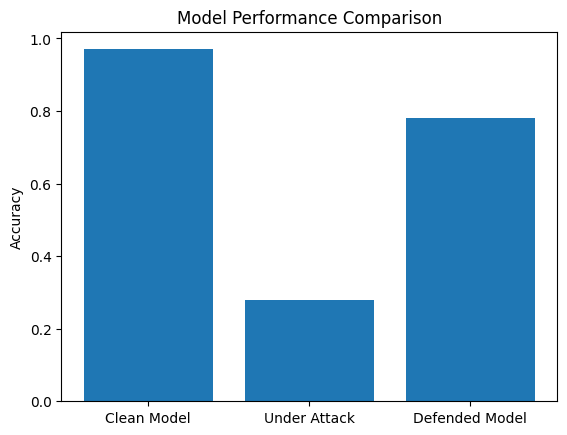

In [12]:
# Compare results
labels = [
    'Clean Model',
    'Under Attack',
    'Defended Model'
]

# Replace with your own values if needed
accuracies = [0.97, 0.28, 0.78]

plt.bar(labels, accuracies)

plt.ylabel('Accuracy')

plt.title('Model Performance Comparison')

plt.show()

## Performance Comparison

The graph compares the accuracy of the clean model, attacked model, and defended model.